In [1]:
# !pip install scikit-learn
# !pip install torch
# !pip install yfinance
# !pip install tqdm

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math
import yfinance as yf
import pandas as pd
import seaborn as sns
import seaborn.objects as so
from keras import Input
from keras import layers, Model
import tensorflow as tf
from tensorflow.keras.optimizers import RMSprop, Adam, SGD
import random
import sys
sys.path.append('../..')
#import ep.etools as apt
# import warnings
# warnings.filterwarnings( "ignore", module = "matplotlib\..*" )
from tqdm import tqdm
from pandas.tseries.offsets import DateOffset,BusinessDay

,Day-ahead,Month-ahead,Quarter-ahead,Summer 24,Winter 24,Year-Ahead,2 Year-Ahead
date_m,,,,,,,
2010-01-01,14.30,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-04,16.25,13.70,NaN,NaN,NaN,NaN,NaN
2010-01-05,14.15,13.96,NaN,NaN,NaN,NaN,NaN
2010-01-06,14.65,13.80,NaN,NaN,NaN,NaN,NaN
2010-01-07,16.18,13.82,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2024-04-22,29.78,29.20,29.91,NaN,34.61,33.40,29.72
2024-04-23,29.09,28.58,29.16,NaN,33.91,33.00,29.50
2024-04-24,30.11,29.33,29.80,NaN,34.38,33.58,29.83


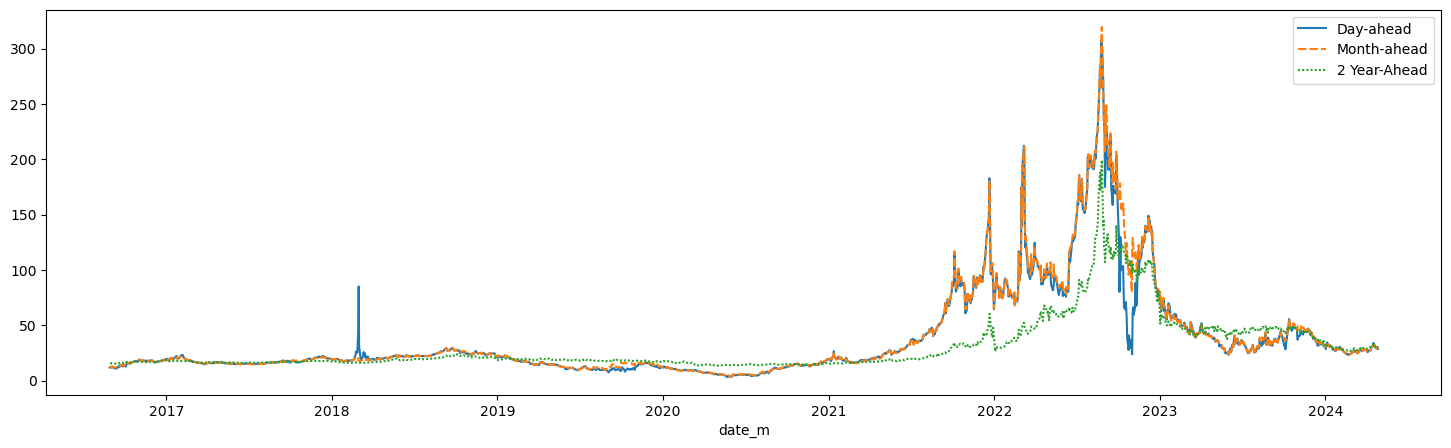

In [4]:
# dataCalendar = pd.read_csv('./data/bloc_ttf_calendar_prices.csv')
dataPrices = pd.read_csv('../../data/bloc_ttf_prices.csv')
dataPrices['date_m'] = pd.to_datetime(dataPrices['date_m'])
dataPrices = dataPrices.set_index('date_m')
fig, ax = plt.subplots(figsize=(18,5))
# sns.set_palette("mako")
sns.lineplot(dataPrices[['Day-ahead','Month-ahead','2 Year-Ahead']][-2000:], color='Blue'); #3390
#ax2 = plt.twinx()
#sns.lineplot(data=final['€/$'], ax=ax2 , color='grey')
dataPrices

## Construction du Transformer

* Normaliser les données

In [4]:
from sklearn.preprocessing import MinMaxScaler

In [5]:
def Normalize(d):
    # seuil = int(d.size*(1-r))
    min_max_scaler = MinMaxScaler()
    # définir le scaler à partir de l'ensemble des données
    scaler = min_max_scaler.fit(d.reshape(-1, 1))
    # mise à l'échelle des données d'apprentissage et de test
    data = scaler.transform(d[:].reshape(-1, 1))
    # train = scaler.transform(d[:seuil].reshape(-1, 1))
    # test = scaler.transform(d[seuil:].reshape(-1, 1))
    return data, min_max_scaler

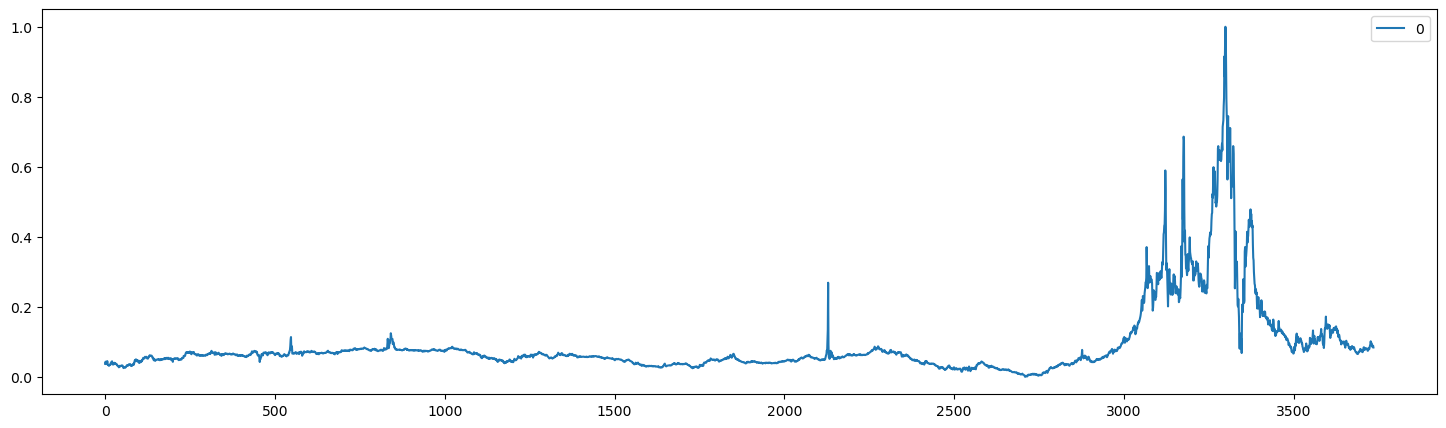

In [6]:
d = dataPrices['Day-ahead'].values
# print(d.reshape(-1,1))
data_train, scaler = Normalize(d)
# pd
fig, ax = plt.subplots(figsize=(18,5))
sns.lineplot(data_train, color='Blue');


(3736, 1)


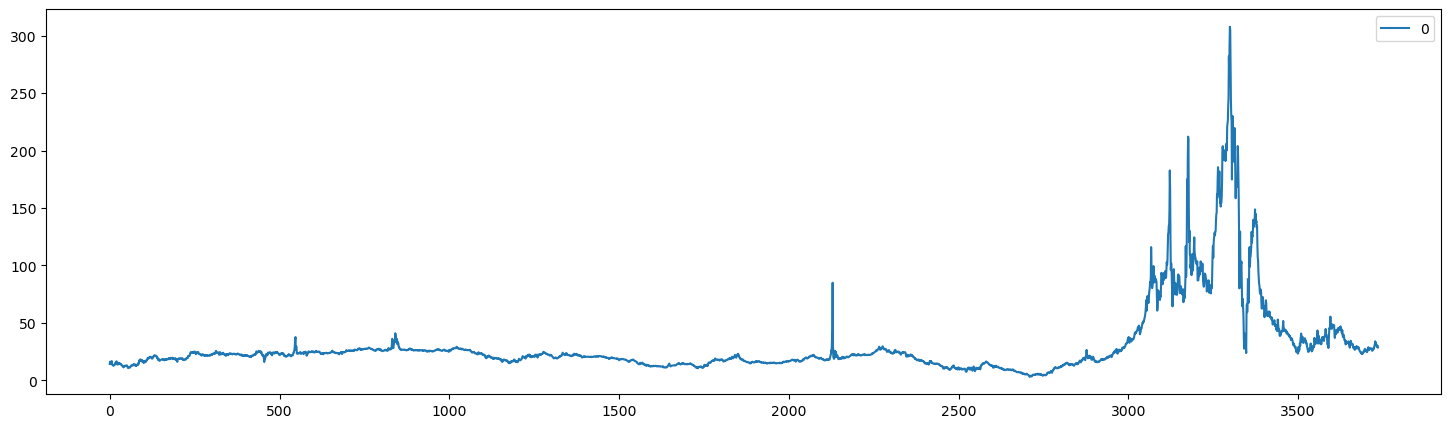

In [7]:
d = scaler.inverse_transform(data_train)
fig, ax = plt.subplots(figsize=(18,5))
sns.lineplot(d[:], color='Blue');
print(d.shape)

In [8]:
def WindowHash(dataset, start_index, end_index, history_size,mask, forward):
    data = []
    labels = []

    start_index = start_index + history_size
    if end_index is None:
        end_index = len(dataset)-mask-forward+1

    for i in range(start_index, end_index):
        indices = range(i - history_size, i)
        indicesY = range(i-mask,i+forward)
        data.append(np.reshape(dataset[indices], (history_size, 1)))
        # labels.append(np.reshape(dataset[i-mask:i+forward],(forward+mask-1,1)))
        # labels.append((dataset[i-mask:i+forward]))
        labels.append((dataset[indicesY]))

    data = np.array(data)
    labels = np.array(labels)

    return data.reshape((data.shape[0],data.shape[1])),labels.reshape((labels.shape[0], labels.shape[1]))

In [9]:
X,y = WindowHash(data_train,0,None,20,2,5)
dataSet =[]
for i in range(X.shape[0]):
        dataSet.append(np.array([X[i],y[i]],dtype=object))

dataSet = np.array(dataSet, dtype=object)
# shuffle(dataSet)
# print(dataSet[0].shape,data_train.shape)
print(X.shape,y.shape,dataSet.shape)
print(dataSet[0,0],dataSet[0,1])

(3710, 20) (3710, 7) (3710, 2)
[0.03671983 0.04311872 0.0362276  0.03786835 0.04288902 0.03731049
 0.04459539 0.03580101 0.03360242 0.03393056 0.03228982 0.03130538
 0.03360242 0.03416027 0.03360242 0.03409464 0.03868872 0.04032946
 0.04190457 0.04170769] [0.04190457 0.04170769 0.04426724 0.03698235 0.03514471 0.03540723
 0.03507908]


### Chargement des libraries

In [10]:
from tensorflow import math, matmul, reshape, shape, transpose, cast, float32
from tensorflow.keras.layers import Dense, Layer, Dropout
from keras.backend import softmax
from numpy import random
# import tensorflow as tf
# from tensorflow import convert_to_tensor, string
from tensorflow.keras.layers import TextVectorization, Embedding
from tensorflow.data import Dataset
import numpy as np

## Positionnal Embedding

In [11]:
class PositionEmbeddingLayer(Layer):
    # def __init__(self, sequence_length, output_dim, **kwargs):
    def __init__(self, sequence_length, vocab_size, output_dim, **kwargs):
        super(PositionEmbeddingLayer, self).__init__(**kwargs)
        self.word_embedding_layer = Embedding(
            input_dim=vocab_size, output_dim=output_dim
        )
        self.position_embedding_layer = Embedding(
            input_dim=sequence_length, output_dim=output_dim
        )
 
    def call(self, inputs):        
        position_indices = tf.range(tf.shape(inputs)[-1])
        embedded_words = self.word_embedding_layer(inputs)
        embedded_indices = self.position_embedding_layer(position_indices)
        return embedded_words + embedded_indices

In [12]:
class PositionEmbeddingFixedWeights(Layer):
    # def __init__(self, sequence_length, output_dim, **kwargs):
    def __init__(self, sequence_length, vocab_size, output_dim, **kwargs):
        super(PositionEmbeddingFixedWeights, self).__init__(**kwargs)
        word_embedding_matrix = self.get_position_encoding(vocab_size, output_dim)   
        position_embedding_matrix = self.get_position_encoding(sequence_length, output_dim)                                          
        self.word_embedding_layer = Embedding(
            input_dim=vocab_size, output_dim=output_dim,
            weights=[word_embedding_matrix],
            trainable=False
        )
        self.position_embedding_layer = Embedding(
            input_dim=sequence_length, output_dim=output_dim,
            weights=[position_embedding_matrix],
            trainable=False
        )
             
    def get_position_encoding(self, seq_len, d, n=10000):
        P = np.zeros((seq_len, d))
        for k in range(seq_len):
            for i in np.arange(int(d/2)):
                denominator = np.power(n, 2*i/d)
                P[k, 2*i] = np.sin(k/denominator)
                P[k, 2*i+1] = np.cos(k/denominator)
        return P
 
 
    def call(self, inputs):        
        position_indices = tf.range(tf.shape(inputs)[-1])
        embedded_words = self.word_embedding_layer(inputs)
        embedded_indices = self.position_embedding_layer(position_indices)
        # print('embedding',embedded_indices.shape, embedded_words.shape)
        # return ((embedded_indices ))
        return ((embedded_words + embedded_indices) +1.)/3.
        # return embedded_indices

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class TokenEmbedding(nn.Module):
    def __init__(self, c_in, d_model):
        super(TokenEmbedding, self).__init__()
        padding = 1 if torch.__version__>='1.5.0' else 2
        self.tokenConv = nn.Conv1d(in_channels=c_in, out_channels=d_model, 
                                    kernel_size=3, padding=padding, padding_mode='circular')
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight,mode='fan_in',nonlinearity='leaky_relu')

    def forward(self, x):
        x = F.normalize(self.tokenConv(x.permute(0, 2, 1)).transpose(1,2))
        return x

class PositionalEmbedding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEmbedding, self).__init__()
        # Compute the positional encodings once in log space.
        pe = torch.zeros(max_len, d_model).float()
        pe.require_grad = False

        position = torch.arange(0, max_len).float().unsqueeze(1)
        div_term = (torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model)).exp()

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return self.pe[:, :x.size(1)]

In [14]:
# from tensorflow import convert_to_tensor, int64, float64

# input_seq_length = 20
# batch_size = 64
# d_model = 512

# idx = 1309
# sequence = np.array(data_train[idx:idx+27]).reshape((27))
# x = sequence[:input_seq_length].reshape(1,input_seq_length)
# x_tf = convert_to_tensor(x, dtype=float64)

# xx = torch.randn((batch_size, input_seq_length, input_seq_length))
# print(xx.shape)
# print(x_tf.shape)
# # xx = reshape(xx, (64, input_seq_length, d_model))
# # print(xx.permute(0,2,1))
# value_embedding = TokenEmbedding(c_in=input_seq_length, d_model=d_model)
# positional_embedding = PositionalEmbedding(d_model=d_model)
# yV = value_embedding(xx)
# yP = positional_embedding(xx)
# print(yP.shape)

# pos = PositionEmbeddingFixedWeights(20,20,512)
# data_pos = pos(x_tf)
# print('Data Position Encoding',data_pos.shape,data_pos.numpy())

# ca1 = plt.matshow(yV.detach().numpy()[0])
# plt.gcf().colorbar(ca1);
# ca2 = plt.matshow(yP.detach().numpy()[0])
# plt.gcf().colorbar(ca2);

# cax = plt.matshow(data_pos[0])
# plt.gcf().colorbar(cax);


In [15]:
# from tensorflow import convert_to_tensor, int64, float64

# pos = PositionEmbeddingFixedWeights(20,20,512)
# idx = 1309
# sequence = np.array(data_train[idx:idx+27]).reshape((27))
# x = sequence[:20].reshape(1,20)
# x_tf = convert_to_tensor(x, dtype=float64)
# data_pos = pos(xx)
# print('Data Position Encoding',data_pos.shape,data_pos.numpy())
# cax = plt.matshow(data_pos[0])
# plt.gcf().colorbar(cax);

# T2V = Time2Vec()
# # T2V.build((20,512))
# dataT2V = T2V(x_tf)
# print(dataT2V)
# # dataPos2vec = pos(dataT2V)
# print(dataT2V.shape,dataT2V.numpy())
# # cay = plt.matshow(dataPos2vec[1]);
# # plt.gcf().colorbar(cay);

In [16]:
class TokenEmbedding(Layer):
    def __init__(self, c_in, c_out, **kwargs):
        super(TokenEmbedding, self).__init__(**kwargs)
        self.c_in = c_in
        self.c_out = c_out
        self.X = tf.keras.layers.Input((c_in,c_in),batch_size=64)
        self.token= tf.keras.layers.Conv1D(filters=c_out, kernel_size=7,activation='relu', use_bias=False, name='conv', padding="same")(self.X)
        self.model = tf.keras.models.Model(inputs = self.X, outputs = self.token )
        
    def call(self, x):
        return self.model.predict(x)

In [17]:
# # from tensorflow import convert_to_tensor, int64, float64

# pos = TokenEmbedding(20,512)
# # print(pos.summary())
# idx = 1309
# sequence = np.array(data_train[idx:idx+27]).reshape((27))
# x = sequence[:20].reshape(1,20,1)
# x_tf = convert_to_tensor(x, dtype=float64)
# xx = random.random((batch_size, input_seq_length, input_seq_length))
# x_tf = convert_to_tensor(xx, dtype=float64)
# print(xx.shape)
# data_pos = pos(x_tf)
# print('Data Position Encoding',data_pos.shape) #,data_pos[0].numpy())
# cax = plt.matshow(data_pos[0])
# plt.gcf().colorbar(cax);

In [18]:
#EMBEDDING

class MyEmbedding(Layer):
    def __init__(self,seq_lenght,output_dim, **kwargs):
        super(Embedding,self).__init__(**kwargs)
        self.value_embedding = TokenEmbedding(seq_lenght,output_dim)
        self.position_embedding = 1
        self.temporal_embedding = 1

    def call(self, inputs):
        embedding = self.value_embedding + self.position_embedding + self.temporal_embedding
        return embedding

### Multi-Head-Attention

In [19]:
# Implementing the Scaled-Dot Product Attention
class DotProductAttention(Layer):
    def __init__(self, **kwargs):
        super(DotProductAttention, self).__init__(**kwargs)
 
    def call(self, queries, keys, values, d_k, mask=None):
        # Scoring the queries against the keys after transposing the latter, and scaling
        scores = matmul(queries, keys, transpose_b=True) / math.sqrt(cast(d_k, float32))
 
        # Apply mask to the attention scores
        if mask is not None:
            scores += -1e9 * mask
 
        # Computing the weights by a softmax operation
        weights = softmax(scores)
 
        # Computing the attention by a weighted sum of the value vectors
        return matmul(weights, values)
 
# Implementing the Multi-Head Attention
class MultiHeadAttention(Layer):
    def __init__(self, h, d_k, d_v, d_model, **kwargs):
        super(MultiHeadAttention, self).__init__(**kwargs)
        self.attention = DotProductAttention()  # Scaled dot product attention
        self.heads = h  # Number of attention heads to use
        self.d_k = d_k  # Dimensionality of the linearly projected queries and keys
        self.d_v = d_v  # Dimensionality of the linearly projected values
        self.d_model = d_model  # Dimensionality of the model
        self.W_q = Dense(d_k)  # Learned projection matrix for the queries
        self.W_k = Dense(d_k)  # Learned projection matrix for the keys
        self.W_v = Dense(d_v)  # Learned projection matrix for the values
        self.W_o = Dense(d_model)  # Learned projection matrix for the multi-head output
 
    def reshape_tensor(self, x, heads, flag):
        if flag:
            # Tensor shape after reshaping and transposing: (batch_size, heads, seq_length, -1)
            # print('x',x.shape)
            x = reshape(x, shape=(shape(x)[0], shape(x)[1], heads, -1))
            x = transpose(x, perm=(0, 2, 1, 3))
        else:
            # Reverting the reshaping and transposing operations: (batch_size, seq_length, d_k)
            x = transpose(x, perm=(0, 2, 1, 3))
            x = reshape(x, shape=(shape(x)[0], shape(x)[1], self.d_k))
        return x
 
    def call(self, queries, keys, values, mask=None):
        # Rearrange the queries to be able to compute all heads in parallel
        # print('queries',queries.shape)
        # print('Dense(q)',self.W_q(queries).shape)
        q_reshaped = self.reshape_tensor(self.W_q(queries), self.heads, True)
        # print(q_reshaped.shape)
        # Resulting tensor shape: (batch_size, heads, input_seq_length, -1)
 
        # Rearrange the keys to be able to compute all heads in parallel
        k_reshaped = self.reshape_tensor(self.W_k(keys), self.heads, True)
        # Resulting tensor shape: (batch_size, heads, input_seq_length, -1)
 
        # Rearrange the values to be able to compute all heads in parallel
        v_reshaped = self.reshape_tensor(self.W_v(values), self.heads, True)
        # Resulting tensor shape: (batch_size, heads, input_seq_length, -1)
 
        # Compute the multi-head attention output using the reshaped queries, keys and values
        o_reshaped = self.attention(q_reshaped, k_reshaped, v_reshaped, self.d_k, mask)
        # Resulting tensor shape: (batch_size, heads, input_seq_length, -1)
 
        # Rearrange back the output into concatenated form
        output = self.reshape_tensor(o_reshaped, self.heads, False)
        # Resulting tensor shape: (batch_size, input_seq_length, d_v)
 
        # Apply one final linear projection to the output to generate the multi-head attention
        # Resulting tensor shape: (batch_size, input_seq_length, d_model)
        return self.W_o(output)

In [20]:
# TEST MULTI HEAD ATTENTION --
input_seq_length = 20  # Maximum length of the input sequence
h = 8  # Number of self-attention heads
d_k = 64  # Dimensionality of the linearly projected queries and keys
d_v = 64  # Dimensionality of the linearly projected values
d_model = 512  # Dimensionality of the model sub-layers' outputs
batch_size = 64  # Batch size from the training process
 
queries = random.random((batch_size, input_seq_length, d_k))
keys = random.random((batch_size, input_seq_length, d_k))
values = random.random((batch_size, input_seq_length, d_v))
 
multihead_attention = MultiHeadAttention(h, d_k, d_v, d_model)
print(multihead_attention(queries, keys, values))

2024-06-23 22:06:16.311331: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2024-06-23 22:06:16.311356: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2024-06-23 22:06:16.311362: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2024-06-23 22:06:16.311394: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-06-23 22:06:16.311408: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


tf.Tensor(
[[[ 0.33279142  0.04394529 -0.20353028 ...  0.18718296  0.31570467
    0.28772515]
  [ 0.3364634   0.04244241 -0.20273343 ...  0.18682854  0.315689
    0.28597483]
  [ 0.33378497  0.04550755 -0.20451383 ...  0.18497257  0.31750104
    0.2871717 ]
  ...
  [ 0.33413804  0.0445785  -0.20373565 ...  0.1848257   0.31444877
    0.28585798]
  [ 0.33436164  0.04362314 -0.20300418 ...  0.18429178  0.315218
    0.2866513 ]
  [ 0.3343462   0.04399913 -0.20374434 ...  0.18548925  0.31596527
    0.28536233]]

 [[ 0.26849446  0.01627049 -0.19176906 ...  0.10249564  0.32115093
    0.3157369 ]
  [ 0.27005327  0.01784419 -0.19149518 ...  0.10217191  0.32079753
    0.3169742 ]
  [ 0.27052468  0.01819796 -0.19078696 ...  0.10236232  0.32074726
    0.31555453]
  ...
  [ 0.26829317  0.01568495 -0.19080353 ...  0.10335439  0.32123294
    0.31700394]
  [ 0.26868635  0.01597742 -0.19042307 ...  0.10311183  0.32057893
    0.3162419 ]
  [ 0.26698327  0.01798817 -0.19033404 ...  0.10012083  0.3200039


### Encoder

In [21]:
from tensorflow.keras.layers import LayerNormalization, Layer, Dense, ReLU, Dropout
# from multihead_attention import MultiHeadAttention
# from positional_encoding import PositionEmbeddingFixedWeights
 
# Implementing the Add & Norm Layer
class AddNormalization(Layer):
    def __init__(self, **kwargs):
        super(AddNormalization, self).__init__(**kwargs)
        self.layer_norm = LayerNormalization()  # Layer normalization layer
 
    def call(self, x, sublayer_x):
        # The sublayer input and output need to be of the same shape to be summed
        add = x + sublayer_x
 
        # Apply layer normalization to the sum
        return self.layer_norm(add)
 
# Implementing the Feed-Forward Layer
class FeedForward(Layer):
    def __init__(self, d_ff, d_model, **kwargs):
        super(FeedForward, self).__init__(**kwargs)
        self.fully_connected1 = Dense(d_ff)  # First fully connected layer
        self.fully_connected2 = Dense(d_model)  # Second fully connected layer
        self.activation = ReLU()  # ReLU activation layer
 
    def call(self, x):
        # The input is passed into the two fully-connected layers, with a ReLU in between
        x_fc1 = self.fully_connected1(x)
 
        return self.fully_connected2(self.activation(x_fc1))
 
# Implementing the Encoder Layer
class EncoderLayer(Layer):
    def __init__(self, sequence_length, h, d_k, d_v, d_model, d_ff, rate, **kwargs):
        super(EncoderLayer, self).__init__(**kwargs)
        self.build(input_shape=[None, sequence_length, d_model])
        self.d_model = d_model
        self.sequence_length = sequence_length
        self.multihead_attention = MultiHeadAttention(h, d_k, d_v, d_model)
        self.dropout1 = Dropout(rate)
        self.add_norm1 = AddNormalization()
        self.feed_forward = FeedForward(d_ff, d_model)
        self.dropout2 = Dropout(rate)
        self.add_norm2 = AddNormalization()
    
    def build_graph(self):
        input_layer = Input(shape=(self.sequence_length, self.d_model))
        return Model(inputs=[input_layer], outputs=self.call(input_layer, None, True))

    def call(self, x, padding_mask, training):
        # Multi-head attention layer
        multihead_output = self.multihead_attention(x, x, x, None)
        # multihead_output = self.multihead_attention(x, x, x, padding_mask) #EP pas de Padding
        # Expected output shape = (batch_size, sequence_length, d_model)
 
        # Add in a dropout layer
        multihead_output = self.dropout1(multihead_output, training=training)
 
        # Followed by an Add & Norm layer
        addnorm_output = self.add_norm1(x, multihead_output)
        # Expected output shape = (batch_size, sequence_length, d_model)
 
        # Followed by a fully connected layer
        feedforward_output = self.feed_forward(addnorm_output)
        # Expected output shape = (batch_size, sequence_length, d_model)
 
        # Add in another dropout layer
        feedforward_output = self.dropout2(feedforward_output, training=training)
 
        # Followed by another Add & Norm layer
        return self.add_norm2(addnorm_output, feedforward_output)
 
# Implementing the Encoder
class Encoder(Layer):
    # def __init__(self, sequence_length, h, d_k, d_v, d_model, d_ff, n, rate, **kwargs):
    def __init__(self, vocab_size, sequence_length, h, d_k, d_v, d_model, d_ff, n, rate, **kwargs):
        super(Encoder, self).__init__(**kwargs)
        # self.pos_encoding = PositionEmbeddingFixedWeights(sequence_length, d_model)
        self.pos_encoding = PositionEmbeddingFixedWeights(sequence_length, vocab_size, d_model)
        self.dropout = Dropout(rate)
        self.encoder_layer = [EncoderLayer(sequence_length, h, d_k, d_v, d_model, d_ff, rate) for _ in range(n)]
 
    def call(self, input_sentence, padding_mask, training):
        # print('Entree:',input_sentence.shape)
        # Generate the positional encoding
        pos_encoding_output = self.pos_encoding(input_sentence)
        # print('pos out', pos_encoding_output.shape )
        # Expected output shape = (batch_size, sequence_length, d_model)
 
        # Add in a dropout layer
        x = self.dropout(pos_encoding_output, training=training)
 
        # Pass on the positional encoded values to each encoder layer
        for i, layer in enumerate(self.encoder_layer):
            x = layer(x, padding_mask, training)

        # print('Sortie:',x.shape)
        return x

In [22]:
## TEST ENCODER

enc_vocab_size = 20 # Vocabulary size for the encoder
input_seq_length = 20 # Maximum length of the input sequence
h = 8  # Number of self-attention heads
d_k = 64  # Dimensionality of the linearly projected queries and keys
d_v = 64  # Dimensionality of the linearly projected values
d_ff = 2048  # Dimensionality of the inner fully connected layer
d_model = 512  # Dimensionality of the model sub-layers' outputs
n = 6  # Number of layers in the encoder stack
 
batch_size = 64  # Batch size from the training process
dropout_rate = 0.1  # Frequency of dropping the input units in the dropout layers
 
input_seq = random.random((batch_size, input_seq_length))
 
# encoder = Encoder(input_seq_length, h, d_k, d_v, d_model, d_ff, n, dropout_rate)
encoder = Encoder(enc_vocab_size, input_seq_length, h, d_k, d_v, d_model, d_ff, n, dropout_rate)

enc_output = encoder(input_seq, None, True)
print('Entree:',input_seq.shape)
print('Sortie:',enc_output.shape)

Entree: (64, 20)
Sortie: (64, 20, 512)


## Decoder

In [23]:
# Implementing the Decoder Layer
class DecoderLayer(Layer):
    def __init__(self, sequence_length, h, d_k, d_v, d_model, d_ff, rate, **kwargs):
        super(DecoderLayer, self).__init__(**kwargs)
        self.build(input_shape=[None, sequence_length, d_model])
        self.d_model = d_model
        self.sequence_length = sequence_length
        self.multihead_attention1 = MultiHeadAttention(h, d_k, d_v, d_model)
        self.dropout1 = Dropout(rate)
        self.add_norm1 = AddNormalization()
        self.multihead_attention2 = MultiHeadAttention(h, d_k, d_v, d_model)
        self.dropout2 = Dropout(rate)
        self.add_norm2 = AddNormalization()
        self.feed_forward = FeedForward(d_ff, d_model)
        self.dropout3 = Dropout(rate)
        self.add_norm3 = AddNormalization()
        
    def build_graph(self):
        input_layer = Input(shape=(self.sequence_length, self.d_model))
        return Model(inputs=[input_layer], outputs=self.call(input_layer, input_layer, None, None, True))

    def call(self, x, encoder_output, lookahead_mask, padding_mask, training):
        # Multi-head attention layer
        multihead_output1 = self.multihead_attention1(x, x, x, lookahead_mask)
        # Expected output shape = (batch_size, sequence_length, d_model)
 
        # Add in a dropout layer
        multihead_output1 = self.dropout1(multihead_output1, training=training)
 
        # Followed by an Add & Norm layer
        addnorm_output1 = self.add_norm1(x, multihead_output1)
        # Expected output shape = (batch_size, sequence_length, d_model)
 
        # Followed by another multi-head attention layer
        multihead_output2 = self.multihead_attention2(addnorm_output1, encoder_output, encoder_output, padding_mask)
 
        # Add in another dropout layer
        multihead_output2 = self.dropout2(multihead_output2, training=training)
 
        # Followed by another Add & Norm layer
        addnorm_output2 = self.add_norm1(addnorm_output1, multihead_output2)
 
        # Followed by a fully connected layer
        feedforward_output = self.feed_forward(addnorm_output2)
        # Expected output shape = (batch_size, sequence_length, d_model)
 
        # Add in another dropout layer
        feedforward_output = self.dropout3(feedforward_output, training=training)
 
        # Followed by another Add & Norm layer
        return self.add_norm3(addnorm_output2, feedforward_output)
 
# Implementing the Decoder
class Decoder(Layer):
    # def __init__(self, sequence_length, h, d_k, d_v, d_model, d_ff, n, rate, **kwargs):
    def __init__(self, vocab_size, sequence_length, h, d_k, d_v, d_model, d_ff, n, rate, **kwargs):
        super(Decoder, self).__init__(**kwargs)
        # self.pos_encoding = PositionEmbeddingFixedWeights(sequence_length, d_model)
        self.pos_encoding = PositionEmbeddingFixedWeights(sequence_length, vocab_size, d_model)
        self.dropout = Dropout(rate)
        self.decoder_layer = [DecoderLayer(sequence_length, h, d_k, d_v, d_model, d_ff, rate) for _ in range(n)]
 
    def call(self, output_target, encoder_output, lookahead_mask, padding_mask, training):
        # Generate the positional encoding
        pos_encoding_output = self.pos_encoding(output_target)
        # Expected output shape = (number of sentences, sequence_length, d_model)
 
        # Add in a dropout layer
        x = self.dropout(pos_encoding_output, training=training)
 
        # Pass on the positional encoded values to each encoder layer
        for i, layer in enumerate(self.decoder_layer):
            x = layer(x, encoder_output, lookahead_mask, padding_mask, training)
 
        return x

In [24]:
## TEST DECODER

dec_vocab_size = 20  # Vocabulary size for the decoder
input_seq_length = 5  # Maximum length of the input sequence
h = 8  # Number of self-attention heads
d_k = 64  # Dimensionality of the linearly projected queries and keys
d_v = 64  # Dimensionality of the linearly projected values
d_ff = 2048  # Dimensionality of the inner fully connected layer
d_model = 512  # Dimensionality of the model sub-layers' outputs
n = 6  # Number of layers in the decoder stack
 
batch_size = 64  # Batch size from the training process
dropout_rate = 0.1  # Frequency of dropping the input units in the dropout layers
 
input_seq = random.random((batch_size, input_seq_length))
enc_output = random.random((batch_size, input_seq_length, d_model))
 
# decoder = Decoder( input_seq_length, h, d_k, d_v, d_model, d_ff, n, dropout_rate)
decoder = Decoder(dec_vocab_size, input_seq_length, h, d_k, d_v, d_model, d_ff, n, dropout_rate)
print(decoder(input_seq, enc_output, None, True))

tf.Tensor(
[[[ 0.6556007   0.76685685 -0.9278355  ...  1.74757     0.00940219
   -1.1107724 ]
  [ 0.71370226  0.74780476 -0.8776351  ...  1.7353021   0.02606291
   -1.0943404 ]
  [ 0.71396506  0.69132835 -0.84420395 ...  1.6908975   0.03723649
   -1.040145  ]
  [ 0.6488536   0.6434106  -0.825951   ...  1.6280833   0.03586627
   -0.97889584]
  [ 0.56369627  0.6457018  -0.82799906 ...  1.5721489   0.02416898
   -0.9123435 ]]

 [[ 0.6873483   0.6169994  -1.0002129  ...  1.3773711   0.28169012
   -1.2615086 ]
  [ 0.7244858   0.5997785  -0.9455076  ...  1.3685396   0.29183435
   -1.2348161 ]
  [ 0.7113184   0.52965593 -0.9071325  ...  1.3217998   0.30390427
   -1.1751364 ]
  [ 0.63728416  0.47790548 -0.8988599  ...  1.23932     0.3007308
   -1.1101611 ]
  [ 0.5618581   0.4819198  -0.91032165 ...  1.1712283   0.30072019
   -1.0400739 ]]

 [[ 0.48734275  0.56174254 -0.9626626  ...  1.867634   -0.00537366
   -1.1618421 ]
  [ 0.5325836   0.54695034 -0.91130024 ...  1.8472518   0.00419609
   -1.

## Transformer

In [25]:
from tensorflow import math, cast, float32, linalg, ones, maximum, newaxis
from tensorflow.keras import Model 
 
class TransformerModel(Model):
    def __init__(self, enc_vocab_size, dec_vocab_size, enc_seq_length, dec_seq_length, h, d_k, d_v, d_model, d_ff_inner, n, rate, **kwargs):
        super(TransformerModel, self).__init__(**kwargs)
 
        # Set up the encoder
        self.encoder = Encoder(enc_vocab_size, enc_seq_length, h, d_k, d_v, d_model, d_ff_inner, n, rate)
 
        # Set up the decoder
        self.decoder = Decoder(dec_vocab_size, dec_seq_length, h, d_k, d_v, d_model, d_ff_inner, n, rate)
 
        # Define the final dense layer
        self.model_last_layer = Dense(dec_vocab_size)
 
    def padding_mask(self, input):
        # Create mask which marks the zero padding values in the input by a 1.0
        mask = math.equal(input, 0)
        mask = cast(mask, float32)
 
        # The shape of the mask should be broadcastable to the shape
        # of the attention weights that it will be masking later on
        return mask[:, newaxis, newaxis, :]
 
    def lookahead_mask(self, shape):
        # Mask out future entries by marking them with a 1.0
        mask = 1 - linalg.band_part(ones((shape, shape)), -1, 0)
 
        return mask
 
    def call(self, encoder_input, decoder_input, training):
        # Create padding mask to mask the encoder inputs and the encoder outputs in the decoder
        # enc_padding_mask = self.padding_mask(encoder_input) # EP pas utile car sequence fixe
 
        # Create and combine padding and look-ahead masks to be fed into the decoder
        # padding_mask = cast( tf.where(loss_mask,tf.ones((decoder_input.shape[0],7)),tf.zeros((decoder_input.shape[0],7))), float64)
        # decoder_input = decoder_input * padding_mask 3 EP Inutile sequence fixe
        dec_in_padding_mask = self.padding_mask(decoder_input)
        dec_in_lookahead_mask = self.lookahead_mask(decoder_input.shape[1])
        dec_in_lookahead_mask = maximum(dec_in_padding_mask, dec_in_lookahead_mask)
 
        # print('Encoder')
        # Feed the input into the encoder
        # encoder_output = self.encoder(encoder_input, None, training)
        # encoder_output = self.encoder(encoder_input, enc_padding_mask, training)
        encoder_output = self.encoder(encoder_input, None, training)
 
        # print('Decoder')
        # Feed the encoder output into the decoder
        decoder_output = self.decoder(decoder_input, encoder_output, dec_in_lookahead_mask, None, training)
        # decoder_output = self.decoder(decoder_input, encoder_output, dec_in_lookahead_mask, enc_padding_mask, training)
 
        # print('Transformer done !')
        # Pass the decoder output through a final dense layer
        model_output = self.model_last_layer(decoder_output)
 
        return model_output

In [26]:
## TEST 
h = 8  # Number of self-attention heads
d_k = 64  # Dimensionality of the linearly projected queries and keys
d_v = 64  # Dimensionality of the linearly projected values
d_ff = 2048  # Dimensionality of the inner fully connected layer
d_model = 512  # Dimensionality of the model sub-layers' outputs
n = 6  # Number of layers in the encoder stack
 
dropout_rate = 0.1  # Frequency of dropping the input units in the dropout layers

enc_vocab_size = 20 # Vocabulary size for the encoder
dec_vocab_size = 20 # Vocabulary size for the decoder
 
enc_seq_length = 20  # Maximum length of the input sequence
dec_seq_length = 20  # Maximum length of the target sequence

training_model = TransformerModel(enc_vocab_size, dec_vocab_size, enc_seq_length, dec_seq_length, h, d_k, d_v, d_model, d_ff, n, dropout_rate)

In [27]:
encoder = EncoderLayer(enc_seq_length, h, d_k, d_v, d_model, d_ff, dropout_rate)
encoder.build_graph().summary()
 
decoder = DecoderLayer(dec_seq_length, h, d_k, d_v, d_model, d_ff, dropout_rate)
decoder.build_graph().summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 20, 512)]    0           []                               
                                                                                                  
 multi_head_attention_37 (Multi  (None, 20, 512)     131776      ['input_1[0][0]',                
 HeadAttention)                                                   'input_1[0][0]',                
                                                                  'input_1[0][0]']                
                                                                                                  
 dropout_64 (Dropout)           (None, 20, 512)      0           ['multi_head_attention_37[0][0]']
                                                                                              

## Training Parameters

In [36]:
from tensorflow.keras.optimizers.legacy import Adam
from tensorflow.keras.optimizers.schedules import LearningRateSchedule
from tensorflow.keras.metrics import Mean
from tensorflow import data, train, math, reduce_sum, cast, equal, argmax, float32, GradientTape, TensorSpec, function, int64
from keras.losses import sparse_categorical_crossentropy, binary_focal_crossentropy, mean_squared_error,poisson
# from model import TransformerModel
# from prepare_dataset import PrepareDataset
from time import time

In [29]:
# Implementing a learning rate scheduler
class LRScheduler(LearningRateSchedule):
    def __init__(self, d_model, warmup_steps=4000, **kwargs):
        super(LRScheduler, self).__init__(**kwargs)
 
        self.d_model = cast(d_model, float32)
        self.warmup_steps = warmup_steps
 
    def __call__(self, step_num):

        step_num = cast(step_num,float32)
 
        # Linearly increasing the learning rate for the first warmup_steps, and decreasing it thereafter
        arg1 = step_num  ** -0.5
        arg2 = step_num * (self.warmup_steps ** -1.5)
 
        return (self.d_model ** -0.5) * math.minimum(arg1, arg2)

In [30]:
range_row = tf.range(0,7,1)
row = tf.expand_dims(range_row,0)
loss_mask = tf.greater(row,1)

In [31]:
# Defining the loss function
def loss_fcn(target, prediction):
    # Create mask so that the zero padding values are not included in the computation of loss
    # padding_mask = math.logical_not(equal(target, 0))
    # padding_mask = cast(padding_mask, float64)
    # padding_mask = cast([1.,1.,1.,1.,1.,1.,1.],float64)
    # padding_mask = cast( tf.where(loss_mask,tf.ones((target.shape[0],7)),tf.zeros((target.shape[0],7))), float64)
    y_true = target #* padding_mask
    y_pred = cast(prediction[:,-1,:], float64) #* padding_mask
 
    # Compute a sparse categorical cross-entropy loss on the unmasked values
    # loss = sparse_categorical_crossentropy(target, prediction, from_logits=False) #* padding_mask
    # loss = poisson(y_true,y_pred)
    loss = binary_focal_crossentropy(y_true,y_pred,from_logits=False)
    # loss = binary_focal_crossentropy(target,prediction[:,-1,:],from_logits=False)
 
    # Compute the mean loss over the unmasked values
    # n = tf.Variable(7.0, dtype=float64)
    return reduce_sum(loss) / 7.0


In [32]:
# Defining the accuracy function
def accuracy_fcn(target, prediction):

    # Create mask so that the zero padding values are not included in the computation of accuracy
    # padding_mask = math.logical_not(equal(target, 0))
    # padding_mask = cast( tf.where(loss_mask,tf.ones((target.shape[0],7)),tf.zeros((target.shape[0],7))), float64)
    # padding_mask = cast([1.,1.,1.,1.,1.,1.,1.],float64)
    y_true = target #* padding_mask
    y_pred = cast(prediction[:,-1,:], float64) #* padding_mask

    # Find equal prediction and target values, and apply the padding mask
    # print(target.shape, prediction.shape)
    # print(argmax(prediction,axis=2))
    # print(prediction[:,:,0])
    # print(target)
    # accuracy = equal(target, cast(argmax(prediction, axis=2),float64))
    # print(target)
    accuracy = abs( (y_true - y_pred))/7.0
    # accuracy = math.logical_and(padding_mask, accuracy)
 
    # Cast the True/False values to 32-bit-precision floating-point numbers
    # padding_mask = cast(padding_mask, float32)
    # accuracy = cast(accuracy, float32)
 
    # Compute the mean accuracy over the unmasked values
    # n = tf.Variable(7.0, dtype=float64)
    return (1 - (reduce_sum(accuracy))*100.0)

# Implementation Finale

* Charger un dataset
* Nettoyer le dataset
* Extraire les valeurs / le réduire [start:stop]
* Normalizer (on récupère le scaler pour l'opération inverse)
* Découpage : [ 1 2 3 4 5] [4 5 6] = (5,2,3)
* Shuffled : on mélange le dataset
* Séparation train et test

NB: Pas besoin de Token ou de START EOS ni de Padding car toutes les 'sentences' sont de même longueur


In [33]:
from tensorflow import convert_to_tensor, int64, float64
from numpy.random import shuffle
from pickle import dump

In [34]:
def PrepareDataset():
    # On récupère les valeurs 
    d = dataPrices['Day-ahead'].values
    # On extrait les dataset Train et Test après normalisation ainsi que la ftc de retour
    data, dataScaler = Normalize(d)
    # Scaling des dataset Input (X) et Outpu(y)
    enc_seq_length = 20
    dec_seq_length = 5
    recouvrement = 2
    # on récupere le DataSet
    X,y = WindowHash(data,0,None,enc_seq_length,recouvrement,dec_seq_length)
    D = np.concatenate([X,y],axis=1)
    # Melange du dataSet
    shuffle(D)
    # Extraction du train et val dataSet
    l = int(D.shape[0] * 0.9)
    trainSet = D[:l]
    valSet = D[l:]
    X_train = np.array(trainSet[:,:enc_seq_length])
    y_train = np.array(trainSet[:,enc_seq_length:])
    X_val = (valSet[:,:enc_seq_length])
    y_val = (valSet[:,enc_seq_length:])
    # X_train, y_train = WindowHash(data_train,0,None,enc_seq_length,recouvrement,dec_seq_length)
    # print(X_train.shape, y_train.shape)
    X_train = convert_to_tensor(X_train, dtype=float64)
    y_train = convert_to_tensor(y_train, dtype=float64)
    X_val = convert_to_tensor(X_val, dtype=float64)
    y_val = convert_to_tensor(y_val, dtype=float64)

    return X_train,y_train,X_val,y_val,data_train,enc_seq_length,dec_seq_length+recouvrement,enc_seq_length,dec_seq_length+recouvrement

# print (X_train[0], y_train[0])

In [37]:
# Speeding up the training process
# @function
def train_step(encoder_input, decoder_input, decoder_output):
    # print(encoder_input, decoder_input,decoder_output)
    with GradientTape() as tape:
 
       # Run the forward pass of the model to generate a prediction
        prediction = training_model(encoder_input, decoder_input, training=True)
 
        # Compute the training loss
        loss = loss_fcn(decoder_output, prediction)

        # Compute the training accuracy
        accuracy = accuracy_fcn(decoder_output, prediction)
 
    # Retrieve gradients of the trainable variables with respect to the training loss
    gradients = tape.gradient(loss, training_model.trainable_weights)
 
    # Update the values of the trainable variables by gradient descent
    optimizer.apply_gradients(zip(gradients, training_model.trainable_weights))
 
    train_loss(loss)
    train_accuracy(accuracy)
#----------------------------
# Define the model parameters
h = 8  # Number of self-attention heads
d_k = 64  # Dimensionality of the linearly projected queries and keys
d_v = 64  # Dimensionality of the linearly projected values
d_model = 512  # Dimensionality of model layers' outputs
d_ff = 2048  # Dimensionality of the inner fully connected layer
n = 6  # Number of layers in the encoder stack
 
# Define the training parameters
epochs = 20
batch_size = 64
beta_1 = 0.9
beta_2 = 0.98
epsilon = 1e-9
dropout_rate = 0.15
 
# Instantiate an Adam optimizer
optimizer = Adam(LRScheduler(d_model), beta_1, beta_2, epsilon)
 
# Prepare the training and test splits of the dataset
# dataset = PrepareDataset()
# trainX, trainY, train_orig, enc_seq_length, dec_seq_length, enc_vocab_size, dec_vocab_size = dataset('english-german-both.pkl')
trainX, trainY, valX, valY, train_orig, enc_seq_length, dec_seq_length, enc_vocab_size, dec_vocab_size = PrepareDataset()
 
# Prepare the dataset batches
train_dataset = data.Dataset.from_tensor_slices((trainX, trainY))
train_dataset = train_dataset.batch(batch_size)

# Prepare the validation dataset batches
val_dataset = data.Dataset.from_tensor_slices((valX, valY))
val_dataset = val_dataset.batch(batch_size)

# Create model
training_model = TransformerModel(enc_vocab_size, dec_vocab_size, enc_seq_length, dec_seq_length, h, d_k, d_v, d_model, d_ff, n, dropout_rate)

# Include metrics monitoring
train_loss = Mean(name='train_loss')
train_accuracy = Mean(name='train_accuracy')
val_loss = Mean(name='val_loss')

# Initialise dictionaries to store the training and validation losses
train_loss_dict = {}
train_accuracy_dict = {}
val_loss_dict = {}

# Create a checkpoint object and manager to manage multiple checkpoints
ckpt = train.Checkpoint(model=training_model, optimizer=optimizer)
ckpt_manager = train.CheckpointManager(ckpt, "./checkpoints", max_to_keep=3)

start_= time()
for epoch in range(epochs): 
    train_loss.reset_states()
    train_accuracy.reset_states() 
    # print("\nStart of epoch %d" % (epoch + 1))
    # Iterate over the dataset batches
    for step, (train_batchX, train_batchY) in enumerate(train_dataset):
 
        # Define the encoder and decoder inputs, and the decoder output
        encoder_input = train_batchX[:, :]
        decoder_input = train_batchY[:, :]
        decoder_output = train_batchY[:, :]
        train_step(encoder_input, decoder_input, decoder_output)
        # if step % 50 == 0:
        #     print(f'Epoch {epoch + 1} Step {step} Loss {train_loss.result():.4f} Accuracy {train_accuracy.result():.4f}')
        #     # print("Samples so far: %s" % ((step + 1) * batch_size))
    # Run a validation step after every epoch of training
    for val_batchX, val_batchY in val_dataset:
        # Define the encoder and decoder inputs, and the decoder output
        encoder_input = val_batchX[:, :]
        decoder_input = val_batchY[:, :]
        decoder_output = val_batchY[:, :]
        # Generate a prediction
        prediction = training_model(encoder_input, decoder_input, training=False) 
        # Compute the validation loss
        loss = loss_fcn(decoder_output, prediction)
        val_loss(loss) 
 
    # Print epoch number and loss value at the end of every epoch
    print("Epoch %d: Training Loss %.4f, Training Accuracy %.4f" % (epoch + 1, train_loss.result(), train_accuracy.result()))
 
    if (epoch + 1) % 1 == 0:
        # Save train/Val loss
        train_loss_dict[epoch] = train_loss.result()
        train_accuracy_dict[epoch] = train_accuracy.result()
        val_loss_dict[epoch] = val_loss.result()
        # Save a checkpoint after every five epochs
        save_path = ckpt_manager.save()
        print("Saved checkpoint at epoch %d" % (epoch + 1))
        # Save the trained model weights
        training_model.save_weights("weights/wghts" + str(epoch + 1) + ".ckpt")
 
# Save the training loss values
with open('./train_loss.pkl', 'wb') as file:
    dump(train_loss_dict, file)

# Save the training accuracy values
with open('./train_accuracy.pkl', 'wb') as file:
    dump(train_accuracy_dict, file)

# Save the validation loss values
with open('./val_loss.pkl', 'wb') as file:
    dump(val_loss_dict, file)
    
print("Total time taken: %.2fs" % (time() - start_time))

2024-06-23 22:09:44.034556: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype double and shape [3339,7]
	 [[{{node Placeholder/_1}}]]
2024-06-23 22:10:09.033912: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype double and shape [371,7]
	 [[{{node Placeholder/_1}}]]


Epoch 1: Training Loss 9.8138, Training Accuracy -5134.3550
Saved checkpoint at epoch 1
Epoch 2: Training Loss 1.8861, Training Accuracy -2422.3691
Saved checkpoint at epoch 2
Epoch 3: Training Loss 1.1462, Training Accuracy -1596.9781
Saved checkpoint at epoch 3
Epoch 4: Training Loss 3.0907, Training Accuracy -1996.4832
Saved checkpoint at epoch 4
Epoch 5: Training Loss 5.5864, Training Accuracy -2620.8818
Saved checkpoint at epoch 5
Epoch 6: Training Loss 1.0309, Training Accuracy -1561.7175
Saved checkpoint at epoch 6
Epoch 7: Training Loss 1.2439, Training Accuracy -1491.5201
Saved checkpoint at epoch 7
Epoch 8: Training Loss 5.6650, Training Accuracy -2954.3982
Saved checkpoint at epoch 8
Epoch 9: Training Loss 1.4428, Training Accuracy -1661.8802
Saved checkpoint at epoch 9
Epoch 10: Training Loss 0.7382, Training Accuracy -1152.1217
Saved checkpoint at epoch 10
Epoch 11: Training Loss 0.9001, Training Accuracy -1261.6710
Saved checkpoint at epoch 11
Epoch 12: Training Loss 1.32

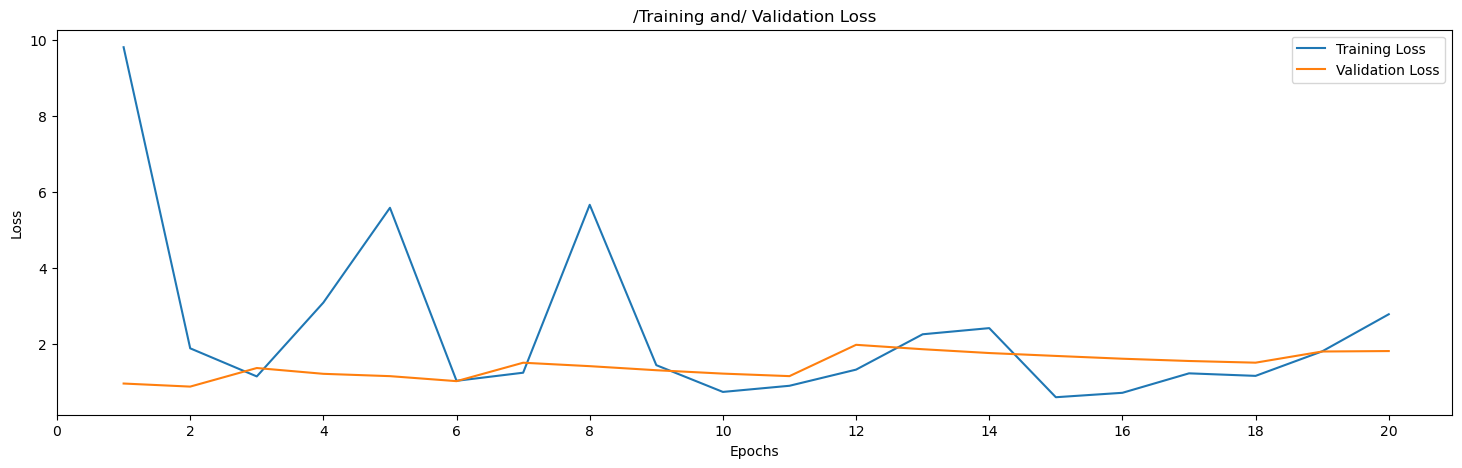

In [38]:
from pickle import load
from matplotlib.pylab import plt
from numpy import arange
 
# Load the training and validation loss dictionaries
train_loss = load(open('train_loss.pkl', 'rb'))
val_loss = load(open('val_loss.pkl', 'rb'))
train_accuracy = load(open('train_accuracy.pkl', 'rb'))
 
# Retrieve each dictionary's values
train_values = train_loss.values()
val_values = val_loss.values()
accuracy_values = train_accuracy.values()
 
# Generate a sequence of integers to represent the epoch numbers
g_epochs = range(1, epochs+1)

fig = plt.figure(figsize=(18,5))
# Plot and label the training and validation loss values
plt.plot(g_epochs, train_values, label='Training Loss')
plt.plot(g_epochs, val_values, label='Validation Loss')
 
# Add in a title and axes labels
plt.title('/Training and/ Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
 
# Set the tick locations
plt.xticks(arange(0, epochs+1, 2))
 
# Display the plot
plt.legend(loc='best')
plt.show()

In [39]:
from pickle import load
from tensorflow import Module

# Define the model parameters
h = 8  # Number of self-attention heads
d_k = 64  # Dimensionality of the linearly projected queries and keys
d_v = 64  # Dimensionality of the linearly projected values
d_model = 512  # Dimensionality of model layers' outputs
d_ff = 2048  # Dimensionality of the inner fully connected layer
n = 6  # Number of layers in the encoder stack
 
# Define the dataset parameters
enc_seq_length = 20  # Encoder sequence length
dec_seq_length = 7  # Decoder sequence length
recouvrement = 2
enc_vocab_size = 20  # Encoder vocabulary size
dec_vocab_size = 7  # Decoder vocabulary size
# Create model
inferencing_model = TransformerModel(enc_vocab_size, dec_vocab_size, enc_seq_length, dec_seq_length, h, d_k, d_v, d_model, d_ff, n, 0)
 
class Prediction(Module):
    def __init__(self, inferencing_model, **kwargs):
        super(Prediction, self).__init__(**kwargs)
        self.transformer = inferencing_model
  
    def __call__(self, sequence):
        # Prepare the input sentence by tokenizing, padding and converting to tensor
        encoder_input = sequence[:enc_seq_length].reshape((1,enc_seq_length))
        encoder_input = convert_to_tensor(encoder_input, dtype=float64)
  
        # Prepare the output array of dynamic size
        decoder_input = sequence[enc_seq_length:]
        # decoder_input[recouvrement] = 0.
        # decoder_input[recouvrement+1] = 0.
        # decoder_input[recouvrement+2] = 0.
        # decoder_input[recouvrement+3] = 0.
        # decoder_input[recouvrement+4] = 0.
        decoder_input = decoder_input.reshape((1,dec_seq_length))
        # print(decoder_input.shape[1],decoder_input)

        decoder_input = convert_to_tensor(decoder_input, dtype=float64)

        # for i in range(dec_seq_length):
        # Predict an output
        prediction = self.transformer(encoder_input, decoder_input, training=False)
        # print(prediction[:,:,:])
        # print(prediction[:,-1,:])
        return(prediction)

 


In [40]:
idx = 1309
sequence = np.array(train_orig[idx:idx+27]).reshape((27))
print(sequence)
y_true = sequence[-7:]

# Load the trained model's weights at the specified epoch
inferencing_model.load_weights('weights/wghts20.ckpt')
 
# Create a new instance of the 'Translate' class
Prev = Prediction(inferencing_model)
 
# Translate the input sentence
y_pred = Prev(sequence)

print(y_true)
print(y_pred[:,-1,:])
accuracy = (((abs((y_true-y_pred[:,-1,:])/y_true))))
print('my acc',reduce_sum(1.-accuracy).numpy())
print(accuracy_fcn(y_true,y_pred).numpy())
print(loss_fcn(y_true,y_pred).numpy())


[0.05365229 0.05332415 0.05460392 0.05480081 0.05503052 0.05509615
 0.05371792 0.05283192 0.05188029 0.05306163 0.05352103 0.05358666
 0.053882   0.05571963 0.05683534 0.0578526  0.05624467 0.05860734
 0.05867297 0.05978867 0.06083875 0.05969023 0.06044497 0.06280764
 0.06599068 0.06887839 0.06651572]
[0.06083875 0.05969023 0.06044497 0.06280764 0.06599068 0.06887839
 0.06651572]
tf.Tensor(
[[-0.12479811  0.07746468  0.00847111  0.16044813 -1.3860617   0.24760662
   0.08047058]], shape=(1, 7), dtype=float32)
my acc -23.57206
-27.53944447327576
0.027927023219364872


In [41]:
m = tf.random.uniform((4,7))
print(m)
range_r = tf.range(0,7,1)
row = tf.expand_dims(range_r,0)
print(row)
mask = tf.greater(row,1)
print(mask)
# res = tf.where(mask,m,tf.zeros((4,7)))
print(m.shape[0])
res = tf.where(mask,tf.ones((4,7)),tf.zeros((4,7)))
print(res)

tf.Tensor(
[[0.31179297 0.8263413  0.6849456  0.0067091  0.78749514 0.3906511
  0.29263055]
 [0.99216926 0.95810425 0.55623317 0.16466296 0.13445711 0.13229859
  0.5348098 ]
 [0.57090175 0.50970507 0.48252344 0.15580535 0.3703227  0.49210668
  0.567016  ]
 [0.2077086  0.18223882 0.99883735 0.36950588 0.37927854 0.7723117
  0.68211746]], shape=(4, 7), dtype=float32)
tf.Tensor([[0 1 2 3 4 5 6]], shape=(1, 7), dtype=int32)
tf.Tensor([[False False  True  True  True  True  True]], shape=(1, 7), dtype=bool)
4
tf.Tensor(
[[0. 0. 1. 1. 1. 1. 1.]
 [0. 0. 1. 1. 1. 1. 1.]
 [0. 0. 1. 1. 1. 1. 1.]
 [0. 0. 1. 1. 1. 1. 1.]], shape=(4, 7), dtype=float32)


In [ ]:
def padding_mask( input):
    # Create mask which marks the zero padding values in the input by a 1.0
    mask = math.equal(input, 0)
    print(mask)
    mask = cast(mask, float32)
    print(mask)

    # The shape of the mask should be broadcastable to the shape
    # of the attention weights that it will be masking later on
    return mask[:, newaxis, newaxis, :]

In [ ]:
idx = 1309
sequence = np.array(train_orig[idx:idx+27]).reshape((27))
x = sequence[:20].reshape(1,20)
x_tf = convert_to_tensor(x, dtype=float64)
print(x_tf.numpy())
mask_x = padding_mask(x_tf)
print(mask_x[0,0,0].numpy())

In [ ]:
def lookahead_mask(shape):
    # Mask out future entries by marking them with a 1.0
    mask = 1 - linalg.band_part(ones((shape, shape)), -1, 0)

    return mask

In [ ]:
lookAH_mask = lookahead_mask(x_tf.shape[1])
print(lookAH_mask)
dec_in_lookahead_mask = maximum(mask_x, lookAH_mask)

In [ ]:
from keras import backend as K
import tensorflow.keras.layers as KL

In [ ]:
class Time2Vec(Layer):
    def __init__(self, kernel_size=1,out_dim=512):
        super(Time2Vec, self).__init__(trainable=True, name='Time2VecLayer')
        self.k = kernel_size
        self.out_dim = out_dim
    
    def build(self, input_shape):
        # trend
        print("iinput", input_shape)
        self.wb = self.add_weight(name='wb',shape=(input_shape[1],),initializer='uniform',trainable=True)
        self.bb = self.add_weight(name='bb',shape=(input_shape[1],),initializer='uniform',trainable=True)
        # periodic
        self.wa = self.add_weight(name='wa',shape=(1, input_shape[1], self.k),initializer='uniform',trainable=True)
        self.ba = self.add_weight(name='ba',shape=(1, input_shape[1], self.k),initializer='uniform',trainable=True)
        super(Time2Vec, self).build(input_shape)
    
    def call(self, inputs, **kwargs):
        print('shape',self.wb.shape,inputs.shape,self.bb.shape)
        bias = self.wb * inputs + self.bb
        dp = K.dot(inputs, self.wa) + self.ba
        wgts = K.sin(dp) # or K.cos(.)

        ret = K.concatenate([K.expand_dims(bias, -1), wgts], -1)
        ret = K.reshape(ret, (inputs.shape[0], inputs.shape[1]*(self.k+1)))
        return ret
    
    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[1]*(self.k + 1))

Data Position Encoding (1, 20, 512) [[[0.33333334 1.         0.33333334 ... 1.         0.33333334 1.        ]
  [0.61382365 0.8467674  0.60728544 ... 1.         0.3333679  1.        ]
  [0.63643247 0.52795106 0.6454716  ... 1.         0.33340243 1.        ]
  ...
  [0.01286751 0.5749455  0.12082428 ... 0.99999946 0.33392075 0.9999995 ]
  [0.08300426 0.8867722  0.00120767 ... 0.99999934 0.33395532 0.99999946]
  [0.3832924  0.9962349  0.16742174 ... 0.9999993  0.33398986 0.99999934]]]


NameError: name 'Time2Vec' is not defined

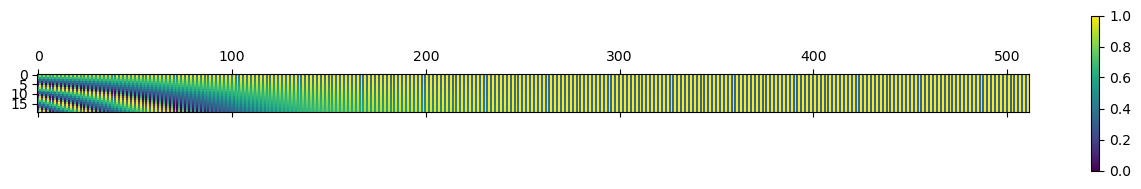

In [42]:
pos = PositionEmbeddingFixedWeights(20,20,512)
idx = 1309
sequence = np.array(train_orig[idx:idx+27]).reshape((27))
x = sequence[:20].reshape(1,20)
x_tf = convert_to_tensor(x, dtype=float64)
data_pos = pos(x_tf)
print('Data Position Encoding',data_pos.shape,data_pos.numpy())
cax = plt.matshow(data_pos[0])
plt.gcf().colorbar(cax);

T2V = Time2Vec()
# T2V.build((20,512))
dataT2V = T2V(x_tf)
print(dataT2V)
# dataPos2vec = pos(dataT2V)
print(dataT2V.shape,dataT2V.numpy())
# cay = plt.matshow(dataPos2vec[1]);
# plt.gcf().colorbar(cay);

In [ ]:
class Time2Vec(KL.Layer):
    """time2vector encoding layer"""

    def __init__(self, kernel: int = 64, activation: str = "sin") -> None:
        """
        Args:
            kernel (int, optional): length of time vector representation. Defaults to 64
            activation (str, optional): periodic activation for time encoding. Defaults to "sin".
        Raises:
            NotImplementedError: Non-supported activations
        """

        # periodic components
        if activation in ["sin", "cos"]:
            activation = {"sin": tf.math.sin, "cos": tf.math.cos}[activation]
        else:
            raise NotImplementedError(
                f"'{activation}' is an unsupported periodic activation."
            )

        super().__init__(trainable=True, name="Time2VecLayer_" + activation.__name__)

        self.k = kernel - 1
        self.p_activation = activation

    def build(self, input_shape: tuple) -> None:
        """method for building and initializing the weights for the tensor operations
        Args:
            input_shape (tuple): shape of the incoming tensor
        """
        # Linear component
        self.w_b = self.add_weight(
            shape=(1, input_shape[1], 1), initializer="uniform", trainable=True
        )

        self.b_b = self.add_weight(
            shape=(1, input_shape[1], 1), initializer="uniform", trainable=True
        )

        # Periodic components
        self.freq = self.add_weight(
            shape=(1, input_shape[1], self.k), initializer="uniform", trainable=True
        )

        self.phase = self.add_weight(
            shape=(1, input_shape[1], self.k), initializer="uniform", trainable=True
        )

        super().build(input_shape)

    def call(self, inputs: tf.Tensor, **kwargs) -> tf.Tensor:

        """method to perform the layer operation
        Args:
            inputs (tf.Tensor): shape = (batch_size, feature_size)
        Returns:
            tf.Tensor: shape = (batch_size, feature_size, length of time vector representation)
        """

        inputs = tf.expand_dims(inputs, axis=-1)

        # Linear components
        lin = (
            # Multiply each time dimension with the corresponding linear time component
            tf.multiply(inputs, self.w_b)
            # Bias component for each time dimension
            + self.b_b
        )

        # Periodic components
        # Multiply each time dimension (M, D, H, mins, etc.) with the corresponding frequency vector
        per = tf.multiply(tf.tile(inputs, multiples=[1, 1, self.k]), self.freq)
        # Phase vector for each time dimension
        per = self.p_activation(per + self.phase)
        return tf.concat([lin, per], -1)

    def compute_output_shape(self, input_shape: tuple) -> tuple:
        """computes the shape of output tensor
        Args:
            input_shape (tuple): shape of incoming tensor
        Returns:
            tuple: shape of outgoing tensor
        """
        return (input_shape[0], input_shape[1], self.k + 1)


In [ ]:
test_vector = tf.random.uniform(shape=(32, 4), dtype=tf.float32)
print(test_vector.shape)
xti = Time2Vec(16, "sin")(test_vector)
# Shape = (32, 4, 16)! 16 dimensional representation for each t-dimension
print(xti.shape)